# Portfolio Submission
Names: Timo Philipse, Ioannis Chatzikos, Kristjana Prifti, Álvaro Buendía, Víctor Carmona 

Date: 04/03/2026


## Contents
- Assignment 1 
- Assignment 2  
- Assignment 3  
- Assignment 4  

# Assignment 1

In [ ]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm_notebook


In [ ]:
# load dataset
data = pd.read_csv('https://raw.githubusercontent.com/aaubs/ds-master/main/data/Swedish_Auto_Insurance_dataset.csv')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       63 non-null     int64  
 1   Y       63 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.1 KB


In [ ]:
data.head()

,X,Y
0,108,392.5
1,19,46.2
2,13,15.7
3,124,422.2
4,40,119.4


In [ ]:
# Using sklearn
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)
data_s = pd.DataFrame(data_scaled, columns=data.columns)

In [ ]:
data_s.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       63 non-null     float64
 1   Y       63 non-null     float64
dtypes: float64(2)
memory usage: 1.1 KB


In [ ]:
data_s.head(3)


,X,Y
0,0.870968,0.929654
1,0.153226,0.109427
2,0.104839,0.037186


The Math Steps:
1. Forward: ŷ = x · w
2. Loss: L = (t - ŷ)²
3. Gradient: ∂L/∂w = 2x(ŷ - t)
4. Update: wnew = wold - α · (∂L/∂w)

In [ ]:
# standardized data (first 3 samples)
x = np.array([0.870968, 0.153226, 0.104839])
t = np.array([0.929654, 0.109427, 0.037186])


w = 1
learning_rate = 1

print(f"{'Sample':<6} {'w_old':<8} {'x':<10} {'ŷ':<10} {'dL/dw':<10} {'w_new':<10}")
print("-"*60)

for i in range(len(x)):
    sample_num = i + 1
    y_hat = x[i] * w
    grad = 2 * x[i] * (y_hat - t[i])
    w_new = w - learning_rate * grad

    print(f"{sample_num:<6} {w:<8.4f} {x[i]:<10.6f} {y_hat:<10.6f} {grad:<10.5f} {w_new:<10.4f}")

    # update weight for next sample
    w = w_new


Sample w_old    x          ŷ          dL/dw      w_new     
------------------------------------------------------------
1      1.0000   0.870968   0.870968   -0.10223   1.1022    
2      1.1022   0.153226   0.168890   0.01822    1.0840    
3      1.0840   0.104839   0.113646   0.01603    1.0680    


# Part B: Attention Contextualization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 2D word embeddings (manually defined)
embeddings = {
    "the": np.array([0.1, 0.1]),
    "light": np.array([0.5, 0.5]),
    "is": np.array([0.2, 0.2]),
    "turned": np.array([0.3, 0.6]),
    "on": np.array([0.4, 0.6]),

    "suitcase": np.array([0.7, 0.3]),
    "empty": np.array([0.8, 0.4]),
    "and": np.array([0.1, 0.3])
}


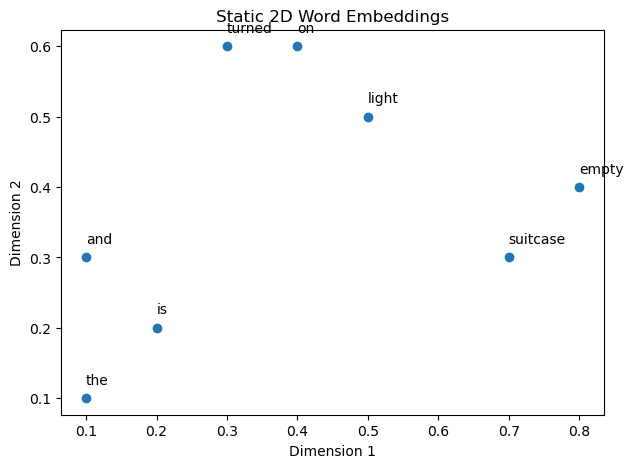

In [ ]:
x_2d = [embeddings[word][0] for word in embeddings]
y_2d = [embeddings[word][1] for word in embeddings]
words_2d = list(embeddings.keys())

plt.figure(figsize=(7,5))
plt.scatter(x_2d, y_2d)

for i, word in enumerate(words_2d):
    plt.text(x_2d[i], y_2d[i]+0.02, word)

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("Static 2D Word Embeddings")
plt.axis("equal")
plt.show()


In [ ]:
sentence_1 = ["the", "light", "is", "turned", "on"]

Q_1 = np.array([embeddings[word] for word in sentence_1])
K_1 = np.array([embeddings[word] for word in sentence_1])
V_1 = np.array([embeddings[word] for word in sentence_1])


In [ ]:
attention_scores_1 = Q_1.dot(K_1.T)
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

attention_weights_1 = np.apply_along_axis(softmax, 1, attention_scores_1)


In [ ]:
attention_output_1 = attention_weights_1.dot(V_1)
light_context_1 = attention_output_1[sentence_1.index("light")]


In [ ]:
sentence_1.append('empty')

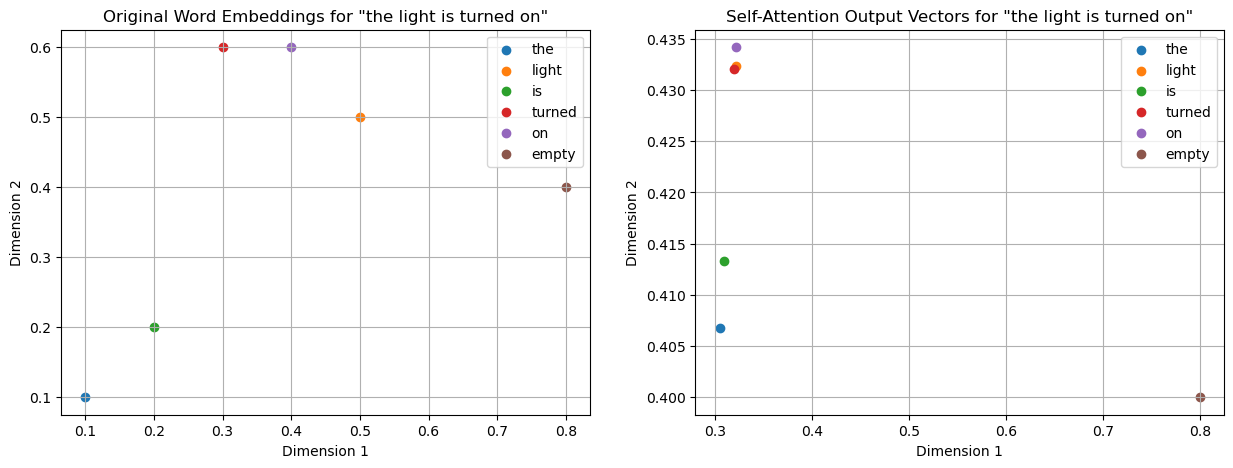

In [ ]:
# Plotting the original embeddings and the attention output for the first sentence "the light is turned on"

# Extract the relevant embeddings for the first sentence
sentence_embeddings_1 = np.array([embeddings[word] for word in sentence_1])

# Reconstruct attention_output_array_1 to match the current sentence_1
# attention_output_1 was calculated for the first 5 words.
# We need to append the embedding of 'empty' to match the 6-word sentence_1.
attention_output_array_1 = np.concatenate((attention_output_1, embeddings['empty'].reshape(1, -1)), axis=0)

# Set up the plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot original embeddings
for i, word in enumerate(sentence_1):
    axes[0].scatter(sentence_embeddings_1[i, 0], sentence_embeddings_1[i, 1], label=f"{word}")

axes[0].set_title('Original Word Embeddings for "the light is turned on"')
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')
axes[0].grid(True)
axes[0].legend()

# Plot output vectors
for i, word in enumerate(sentence_1):
    axes[1].scatter(attention_output_array_1[i, 0], attention_output_array_1[i, 1], label=f"{word}")

axes[1].set_title('Self-Attention Output Vectors for "the light is turned on"')
axes[1].set_xlabel('Dimension 1')
axes[1].set_ylabel('Dimension 2')
axes[1].grid(True)
axes[1].legend()

plt.show()

We see that now 'turned' and 'on' are relatively close to ligth compared to empty

In [ ]:
sentence_2 = ["the", "suitcase", "is", "empty", "and", "light"]

Q_2 = np.array([embeddings[word] for word in sentence_2])
K_2 = np.array([embeddings[word] for word in sentence_2])
V_2 = np.array([embeddings[word] for word in sentence_2])


In [ ]:
attention_scores_2 = Q_2.dot(K_2.T)
attention_weights_2 = np.apply_along_axis(softmax, 1, attention_scores_2)
attention_output_2 = attention_weights_2.dot(V_2)
light_context_2 = attention_output_2[sentence_2.index("light")]

In [ ]:
attention_scores_2 = Q_2.dot(K_2.T)
attention_weights_2 = np.apply_along_axis(softmax, 1, attention_scores_2)
attention_output_2 = attention_weights_2.dot(V_2)
light_context_2 = attention_output_2[sentence_2.index("light")]


In [ ]:
sentence_2.append('turned')

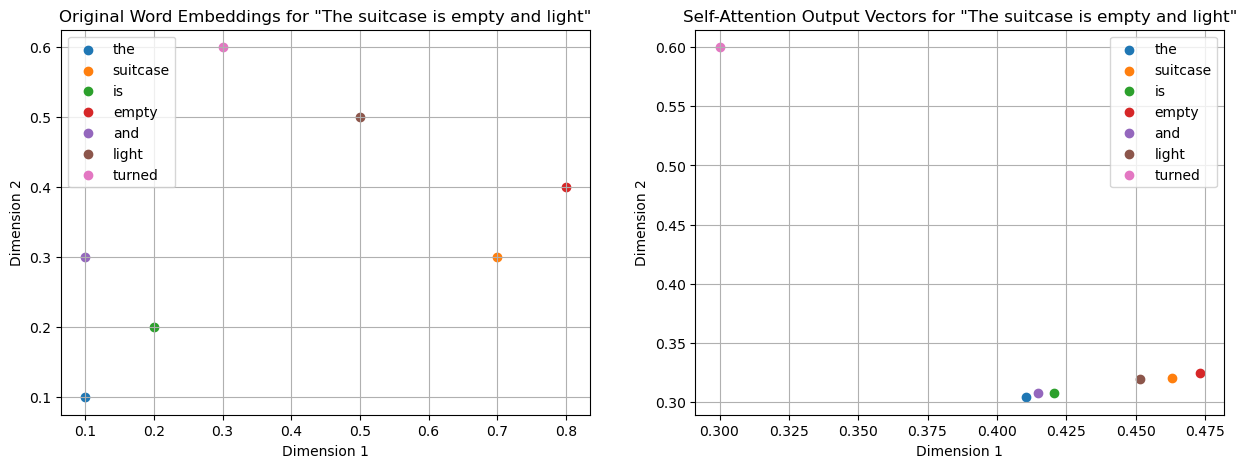

In [ ]:
# Plotting the original embeddings and the attention output for the first sentence "the suitcase is empty and light"

# Extract the relevant embeddings for the first sentence
sentence_embeddings_2 = np.array([embeddings[word] for word in sentence_2])

# Reconstruct attention_output_array_1 to match the current sentence_1
# attention_output_1 was calculated for the first 5 words.
# We need to append the embedding of 'turned' to match the 6-word sentence_1.
attention_output_array_2 = np.concatenate((attention_output_2, embeddings['turned'].reshape(1, -1)), axis=0)

# Set up the plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot original embeddings
for i, word in enumerate(sentence_2):
    axes[0].scatter(sentence_embeddings_2[i, 0], sentence_embeddings_2[i, 1], label=f"{word}")

axes[0].set_title('Original Word Embeddings for "The suitcase is empty and light"')
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')
axes[0].grid(True)
axes[0].legend()

# Plot output vectors
for i, word in enumerate(sentence_2):
    axes[1].scatter(attention_output_array_2[i, 0], attention_output_array_2[i, 1], label=f"{word}")

axes[1].set_title('Self-Attention Output Vectors for "The suitcase is empty and light"')
axes[1].set_xlabel('Dimension 1')
axes[1].set_ylabel('Dimension 2')
axes[1].grid(True)
axes[1].legend()

plt.show()

In [ ]:
def cosine_similarity(a, b):
    return (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))

print("Contextual 'light' (brightness):", light_context_1)
print("Contextual 'light' (weight):", light_context_2)

sim = cosine_similarity(light_context_1, light_context_2)
print("Cosine similarity:", sim)


Contextual 'light' (brightness): [0.32105604 0.43231874]
Contextual 'light' (weight): [0.45146599 0.31947285]
Cosine similarity: 0.9504261998950363


---
# Assignment 2
---

# **Fixing the dataset**

In [ ]:
from datasets import load_dataset
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, TrainingArguments, Trainer
from tqdm import tqdm
from pydantic import BaseModel, Field
from typing import Literal
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from datasets import Dataset

ds = load_dataset("AI-Growth-Lab/patents_claims_1.5m_traim_test")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


df_claim_train_1M_pre_duplicates_removed(…):   0%|          | 0.00/3.25G [00:00<?, ?B/s]

df_claim_test_1M_pre_duplicates_removed_(…):   0%|          | 0.00/283M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1372910 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/119384 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/18 [00:00<?, ?it/s]

In [ ]:
ds

DatasetDict({
    train: Dataset({
        features: ['id', 'date', 'text', 'A01B', 'A01C', 'A01D', 'A01F', 'A01G', 'A01H', 'A01J', 'A01K', 'A01L', 'A01M', 'A01N', 'A21B', 'A21C', 'A21D', 'A22B', 'A22C', 'A23B', 'A23C', 'A23D', 'A23F', 'A23G', 'A23J', 'A23K', 'A23L', 'A23N', 'A23P', 'A23V', 'A23Y', 'A24B', 'A24C', 'A24D', 'A24F', 'A41B', 'A41C', 'A41D', 'A41F', 'A41G', 'A41H', 'A42B', 'A42C', 'A43B', 'A43C', 'A43D', 'A44B', 'A44C', 'A44D', 'A45B', 'A45C', 'A45D', 'A45F', 'A46B', 'A46D', 'A47B', 'A47C', 'A47D', 'A47F', 'A47G', 'A47H', 'A47J', 'A47K', 'A47L', 'A61B', 'A61C', 'A61D', 'A61F', 'A61G', 'A61H', 'A61J', 'A61K', 'A61L', 'A61M', 'A61N', 'A61P', 'A61Q', 'A62B', 'A62C', 'A62D', 'A63B', 'A63C', 'A63D', 'A63F', 'A63G', 'A63H', 'A63J', 'A63K', 'B01B', 'B01D', 'B01F', 'B01J', 'B01L', 'B02B', 'B02C', 'B03B', 'B03C', 'B03D', 'B04B', 'B04C', 'B05B', 'B05C', 'B05D', 'B06B', 'B07B', 'B07C', 'B08B', 'B09B', 'B09C', 'B21B', 'B21C', 'B21D', 'B21F', 'B21G', 'B21H', 'B21J', 'B21K', 'B21L', 'B22

In [ ]:
train = ds["train"]

In [ ]:
print(train.column_names)


['id', 'date', 'text', 'A01B', 'A01C', 'A01D', 'A01F', 'A01G', 'A01H', 'A01J', 'A01K', 'A01L', 'A01M', 'A01N', 'A21B', 'A21C', 'A21D', 'A22B', 'A22C', 'A23B', 'A23C', 'A23D', 'A23F', 'A23G', 'A23J', 'A23K', 'A23L', 'A23N', 'A23P', 'A23V', 'A23Y', 'A24B', 'A24C', 'A24D', 'A24F', 'A41B', 'A41C', 'A41D', 'A41F', 'A41G', 'A41H', 'A42B', 'A42C', 'A43B', 'A43C', 'A43D', 'A44B', 'A44C', 'A44D', 'A45B', 'A45C', 'A45D', 'A45F', 'A46B', 'A46D', 'A47B', 'A47C', 'A47D', 'A47F', 'A47G', 'A47H', 'A47J', 'A47K', 'A47L', 'A61B', 'A61C', 'A61D', 'A61F', 'A61G', 'A61H', 'A61J', 'A61K', 'A61L', 'A61M', 'A61N', 'A61P', 'A61Q', 'A62B', 'A62C', 'A62D', 'A63B', 'A63C', 'A63D', 'A63F', 'A63G', 'A63H', 'A63J', 'A63K', 'B01B', 'B01D', 'B01F', 'B01J', 'B01L', 'B02B', 'B02C', 'B03B', 'B03C', 'B03D', 'B04B', 'B04C', 'B05B', 'B05C', 'B05D', 'B06B', 'B07B', 'B07C', 'B08B', 'B09B', 'B09C', 'B21B', 'B21C', 'B21D', 'B21F', 'B21G', 'B21H', 'B21J', 'B21K', 'B21L', 'B22C', 'B22D', 'B22F', 'B23B', 'B23C', 'B23D', 'B23F', '

In [ ]:


y02_cols = ['Y02A','Y02B','Y02C','Y02D','Y02E','Y02P','Y02T','Y02W']

train = train.add_column(
    "is_green_silver",
    np.any(np.column_stack([train[c] for c in y02_cols]), axis=1).astype(int)
)


In [ ]:
pd.Series(train["is_green_silver"]).value_counts()


,count
0,1269218
1,103692


In [ ]:
green = train.filter(lambda x: x["is_green_silver"] == 1)\
             .shuffle(seed=42)\
             .select(range(25000))

nongreen = train.filter(lambda x: x["is_green_silver"] == 0)\
                .shuffle(seed=42)\
                .select(range(25000))


Filter:   0%|          | 0/1372910 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1372910 [00:00<?, ? examples/s]

In [ ]:
df = pd.concat([
    green.to_pandas(),
    nongreen.to_pandas()
]).sample(frac=1, random_state=42)  


In [ ]:
print(len(df))
print(df["is_green_silver"].value_counts())


50000
is_green_silver
0    25000
1    25000
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.4, stratify=df["is_green_silver"], random_state=42)
pool_df, eval_df  = train_test_split(temp_df, test_size=0.5, stratify=temp_df["is_green_silver"], random_state=42)

train_df["split"] = "train_silver"
pool_df["split"]  = "pool_unlabeled"
eval_df["split"]  = "eval_silver"

final_df = pd.concat([train_df, pool_df, eval_df])


In [ ]:
final_df.to_parquet("patents_50k_green.parquet", index=False)


## Start of Part A

In [ ]:

df = pd.read_parquet("patents_50k_green.parquet")


In [ ]:
MODEL_NAME = "AI-Growth-Lab/PatentSBERTa"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.eval()
model.cuda()  

def embed_texts(texts, batch_size=16):
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]

        tokens = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors="pt"
        ).to(model.device)

        with torch.no_grad():
            outputs = model(**tokens)
            embeddings = outputs.last_hidden_state.mean(dim=1)

        all_embeddings.append(embeddings.cpu().numpy())

    return np.vstack(all_embeddings)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/671 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/440 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: AI-Growth-Lab/PatentSBERTa
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

In [ ]:
train_df = df[df["split"] == "train_silver"]
pool_df  = df[df["split"] == "pool_unlabeled"]
eval_df  = df[df["split"] == "eval_silver"]


In [ ]:
df = pd.read_parquet("patents_50k_green.parquet")

train_texts = df[df.split=="train_silver"]["text"].tolist()
eval_texts  = df[df.split=="eval_silver"]["text"].tolist()
pool_texts  = df[df.split=="pool_unlabeled"]["text"].tolist()

X_train = embed_texts(train_texts)
X_eval  = embed_texts(eval_texts)
X_pool  = embed_texts(pool_texts)

y_train = df[df.split=="train_silver"]["is_green_silver"].values
y_eval  = df[df.split=="eval_silver"]["is_green_silver"].values

np.save("X_train.npy", X_train)
np.save("X_eval.npy", X_eval)
np.save("X_pool.npy", X_pool)
np.save("y_train.npy", y_train)
np.save("y_eval.npy", y_eval)


100%|██████████| 625/625 [02:30<00:00,  4.15it/s]


In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression

X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")

clf = LogisticRegression(max_iter=1000, n_jobs=-1)
clf.fit(X_train, y_train)


LogisticRegression(max_iter=1000, n_jobs=-1)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

X_eval = np.load("X_eval.npy")
y_eval = np.load("y_eval.npy")

y_pred = clf.predict(X_eval)
y_prob = clf.predict_proba(X_eval)

print(classification_report(y_eval, y_pred, digits=4))
print(confusion_matrix(y_eval, y_pred))


              precision    recall  f1-score   support

           0     0.7761    0.7908    0.7834      5000
           1     0.7867    0.7718    0.7792      5000

    accuracy                         0.7813     10000
   macro avg     0.7814    0.7813    0.7813     10000
weighted avg     0.7814    0.7813    0.7813     10000

[[3954 1046]
 [1141 3859]]


## Baseline Model Performance

### Classification Metrics

| Metric | Score |
|--------|--------|
| Accuracy | 0.7813 |
| General F1 Score | 0.7813 |
| Macro Average F1 | 0.7813 |
| Weighted Average F1 | 0.7813 |

---

###  Summary
The baseline model achieved **78.13% accuracy** with a balanced F1-score of **0.7813**, indicating stable performance across both classes.

In [ ]:
df.head()

,id,date,text,A01B,A01C,A01D,A01F,A01G,A01H,A01J,...,Y02D,Y02E,Y02P,Y02T,Y02W,Y04S,Y10S,Y10T,is_green_silver,split
0,8894939,2014-11-25,1. A single stage Fischer-Tropsch reactor syst...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,train_silver
1,9633799,2017-04-25,1. An electrical energy storage assembly compr...,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,train_silver
2,8660772,2014-02-25,1. A liquid concentration measuring device com...,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,train_silver
3,9201337,2015-12-01,"1. A developing roller comprising a shaft, an ...",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,train_silver
4,9833733,2017-12-05,1. An apparatus for separating at least one of...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,train_silver


In [ ]:
joblib.dump(clf, "baseline_logreg_patent.pkl")
print("Baseline model saved.")

Baseline model saved.


## Part B

In [ ]:

p_green = clf.predict_proba(X_pool)[:,1]

# Compute uncertainty: u = 1 - 2*|p-0.5|
u = 1 - 2 * np.abs(p_green - 0.5)

pool_df["p_green"] = p_green
pool_df["u"] = u

# Select top 100 high-uncertainty examples
hitl_df = pool_df.nlargest(100, "u").copy()

# Prepare HITL CSV
hitl_df = hitl_df[["text"]].copy()
hitl_df["doc_id"] = range(1, len(hitl_df)+1)
hitl_df["p_green"] = pool_df.loc[hitl_df.index, "p_green"]
hitl_df["u"] = pool_df.loc[hitl_df.index, "u"]
hitl_df["llm_green_suggested"] = ""
hitl_df["llm_confidence"] = ""
hitl_df["llm_rationale"] = ""
hitl_df["is_green_human"] = ""
hitl_df["human_notes"] = ""


hitl_df.to_csv("hitl_green_100.csv", index=False)

print("Top 100 high-risk examples saved to hitl_green_100.csv")
print(hitl_df.head())


Top 100 high-risk examples saved to hitl_green_100.csv
                                                    text  doc_id   p_green  \
32705  1. A process for producing formation fluids co...       1  0.499926   
31574  1. A method for producing a vehicle body, the ...       2  0.500110   
37206  1. A method for controlling rotation speed of ...       3  0.499871   
33481  1. A method comprising: receiving a first sign...       4  0.499839   
34582  1. A bio-sensing device suitable for the detec...       5  0.500167   

              u llm_green_suggested llm_confidence llm_rationale  \
32705  0.999853                                                    
31574  0.999780                                                    
37206  0.999741                                                    
33481  0.999677                                                    
34582  0.999665                                                    

      is_green_human human_notes  
32705                           

## Part C

In [ ]:
hitl_100 = pd.read_csv('hitl_green_100.csv')
display(hitl_100.head())

,text,doc_id,p_green,u,llm_green_suggested,llm_confidence,llm_rationale,is_green_human,human_notes
0,1. A process for producing formation fluids co...,1,0.499926,0.999853,NaN,NaN,NaN,NaN,NaN
1,"1. A method for producing a vehicle body, the ...",2,0.500110,0.999780,NaN,NaN,NaN,NaN,NaN
2,1. A method for controlling rotation speed of ...,3,0.499871,0.999741,NaN,NaN,NaN,NaN,NaN
3,1. A method comprising: receiving a first sign...,4,0.499839,0.999677,NaN,NaN,NaN,NaN,NaN
4,1. A bio-sensing device suitable for the detec...,5,0.500167,0.999665,NaN,NaN,NaN,NaN,NaN


In [ ]:


# Define the Structured Output Schema
class GreenPatentAnalysis(BaseModel):
    """Analysis of a patent claim for green technology classification."""
    is_green: int = Field(description="1 if the claim is green technology, 0 otherwise.")
    confidence: Literal["low", "medium", "high"] = Field(description="LLM's confidence level.")
    rationale: str = Field(description="1-3 sentences citing specific phrases from the claim.")

#  Update the State
class LabelState(TypedDict):
    doc_id: str
    text: str
    analysis: GreenPatentAnalysis  
    is_green_human: int        

# Structured LLM Node
def llm_analyzer(state: LabelState):
    llm = ChatOpenAI(model="gpt-4o", temperature=0)
    # This binds the schema to the LLM for native structured output
    structured_llm = llm.with_structured_output(GreenPatentAnalysis)
    
    msg = f"Determine if this patent claim is Green Tech:\n\n{state['text']}"
    result = structured_llm.invoke(msg)
    
    return {"analysis": result}

#  Human Review Node 
def human_review(state: LabelState):
    analysis = state["analysis"]
    print(f"\n--- [DOC: {state['doc_id']}] ---")
    print(f"CLAIM: {state['text'][:150]}...")
    print(f"LLM SUGGESTION: {analysis.is_green} ({analysis.confidence})")
    print(f"RATIONALE: {analysis.rationale}")
    
   
    decision = interrupt("Confirm label (0 or 1):")
    return {"is_green_human": int(decision)}


workflow = StateGraph(LabelState)
workflow.add_node("llm_analyzer", llm_analyzer)
workflow.add_node("human_review", human_review)

workflow.add_edge(START, "llm_analyzer")
workflow.add_edge("llm_analyzer", "human_review")
workflow.add_edge("human_review", END)

memory = InMemorySaver()
app = workflow.compile(checkpointer=memory)

In [ ]:
final_gold_data = []

for _, row in hitl_100.iterrows():
    config = {"configurable": {"thread_id": row['doc_id']}}
    
    #Start the process 
    app.invoke({"text": row['text'], "doc_id": row['doc_id']}, config)
    
    # Get the user decision
    user_choice = input(f"Enter final label for {row['doc_id']}: ")
    
    
    
    final_state = app.invoke(Command(resume=user_choice), config)
    final_gold_data.append(final_state)

# Export the gold data 
gold_df = pd.DataFrame(final_gold_data)
gold_df.to_csv("gold_labeled_patents.csv", index=False)


--- [DOC: 1] ---
CLAIM: 1. A process for producing formation fluids comprising: conducting subterranean formation fluid into a wellbore from a subterranean formation; separat...
LLM SUGGESTION: 0 (high)
RATIONALE: The claim describes a process for extracting and separating formation fluids, which primarily involves the handling of oil and gas. The focus is on efficient extraction and separation rather than environmental benefits or sustainability, which are key aspects of green technology.

--- [DOC: 1] ---
CLAIM: 1. A process for producing formation fluids comprising: conducting subterranean formation fluid into a wellbore from a subterranean formation; separat...
LLM SUGGESTION: 0 (high)
RATIONALE: The claim describes a process for extracting and separating formation fluids, which primarily involves the handling of oil and gas. The focus is on efficient extraction and separation rather than environmental benefits or sustainability, which are key aspects of green technology.

--- [DO

In [ ]:
import pandas as pd

# Example DataFrame
  # or whatever your file is

# Extract the LLM prediction from the analysis string
gold_df['llm_green'] = gold_df['analysis'].str.extract(r'is_green=(\d)')[0].astype(int)


In [ ]:
# Compare LLM vs human
gold_df['llm_correct'] = gold_df['llm_green'] == gold_df['is_green_human']

# Accuracy of LLM
accuracy = gold_df['llm_correct'].mean()
print(f"LLM Accuracy vs Human: {accuracy:.2%}")

# Count disagreements
disagreements = gold_df[gold_df['llm_correct'] == False]
print(f"Number of disagreements: {len(disagreements)}")


LLM Accuracy vs Human: 94.00%
Number of disagreements: 6


In [ ]:
disagreements = gold_df[gold_df['llm_green'] != gold_df['is_green_human']]
disagreements.to_excel('hitl_analysis_full.xlsx', index=False)

    doc_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

## Part D

In [ ]:
df_all = pd.read_parquet("patents_50k_green.parquet")
gold_df = pd.read_csv("gold_labeled_patents.csv")

In [ ]:

# We use the raw text as the key since IDs are mismatched
gold_text_map = dict(zip(gold_df['text'], gold_df['is_green_human']))

#  Update df_all 
def resolve_gold_label(row):
    if row['text'] in gold_text_map:
        return gold_text_map[row['text']]
   
    return row['is_green_silver']

df_all['is_green_gold'] = df_all.apply(resolve_gold_label, axis=1)

# Create the final training set
# Filter for rows that are either in the train split OR were part of our 100 gold samples
train_final = df_all[
    (df_all['split'] == 'train_silver') | 
    (df_all['text'].isin(gold_text_map.keys()))
].copy()

print(f"Merged successfully. Gold labels applied to {len(gold_text_map)} rows.")

Merged successfully. Gold labels applied to 100 rows.


In [ ]:

# TRAINING + EVALUATION CELL


import numpy as np
import pandas as pd

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from datasets import Dataset
from sklearn.metrics import classification_report


# Load Model & Tokenizer


model_name = "AI-Growth-Lab/PatentSBERTa"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)


# Tokenization Function


def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )


# Prepare Dataset Splits


train_final_df = df_all[df_all["split"] == "train_silver"]
eval_final_df = df_all[df_all["split"] == "eval_silver"]

train_ds = Dataset.from_pandas(
    train_final_df[["text", "is_green_gold"]]
    .rename(columns={"is_green_gold": "label"})
).map(tokenize_fn, batched=True)

eval_ds = Dataset.from_pandas(
    eval_final_df[["text", "is_green_gold"]]
    .rename(columns={"is_green_gold": "label"})
).map(tokenize_fn, batched=True)

# Remove index column if exists
train_ds = train_ds.remove_columns([c for c in train_ds.column_names if "index" in c])
eval_ds = eval_ds.remove_columns([c for c in eval_ds.column_names if "index" in c])


# Metrics Function


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    report = classification_report(
        labels,
        preds,
        output_dict=True
    )

    return {
        "accuracy": report["accuracy"],
        "f1": report["weighted avg"]["f1-score"],
        "precision": report["weighted avg"]["precision"],
        "recall": report["weighted avg"]["recall"]
    }


# Training Arguments


training_args = TrainingArguments(
    output_dir="./patent_sbert_final",
    learning_rate=2e-5,
    num_train_epochs=1,
    per_device_train_batch_size=16,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",
    push_to_hub=False
)


# Trainer Setup


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    compute_metrics=compute_metrics
)


# Train + Evaluate


trainer.train()

print("\nEvaluation Results:")
eval_results = trainer.evaluate()
print(eval_results)

## Silver Dataset Evaluation Results

| Metric | Value |
|--------|--------|
| Loss | 0.4154 |
| Accuracy | 0.8079 |
| F1 Score | 0.8078 |
| Precision | 0.8081 |
| Recall | 0.8076 |
| Runtime (seconds) | 168.81 |
| Samples per Second | 59.24 |
| Steps per Second | 7.41 |
| Model Preparation Time (seconds) | 0.0025 |

---

### 🔎 Summary
The model performed consistently on the **silver dataset**, achieving approximately **80.79% accuracy** and balanced precision/recall/F1 scores, indicating stable generalization performance.

### Upload the dataset and model to HuggingFace

In [ ]:
hf_dataset = Dataset.from_pandas(df_all)


In [ ]:
dataset_repo_name = "TimoPh/patent-claims-50k-green"

# Push dataset
hf_dataset.push_to_hub(dataset_repo_name, private=False)  


In [ ]:
# Save locally
output_dir = "./patent-classifier-final"

# Save model weights and config
model.save_pretrained(output_dir)

# Save tokenizer
tokenizer.save_pretrained(output_dir)

print(f"Model and tokenizer saved to {output_dir}")


In [ ]:

output_dir = "./patent-classifier-final"
repo_name = "TimoPh/patent-classifier-final" 

# Load the trained model & tokenizer
model = AutoModelForSequenceClassification.from_pretrained(output_dir)
tokenizer = AutoTokenizer.from_pretrained(output_dir)

# Push to Hugging Face Hub
model.push_to_hub(repo_name)
tokenizer.push_to_hub(repo_name)

print(f"Model and tokenizer pushed to https://huggingface.co/{repo_name}")


---
# Assignment 3
---

In [ ]:
from datasets import load_dataset
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from pydantic import BaseModel, Field
from typing import Literal
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from datasets import Dataset
from sklearn.metrics import classification_report

In [ ]:
df2 = pd.read_parquet("patents_50k_green.parquet")


In [ ]:
df =  pd.read_csv("hitl_green_100.csv")

In [ ]:
for col in [
    "advocate_argument",
    "skeptic_argument",
    "judge_label",
    "judge_confidence",
    "judge_rationale",
    "is_green_gold"
]:
    if col not in df.columns:
        df[col] = ""


In [ ]:
df.head()

,text,doc_id,p_green,u,llm_green_suggested,llm_confidence,llm_rationale,is_green_human,human_notes,advocate_argument,skeptic_argument,judge_label,judge_confidence,judge_rationale,is_green_gold
0,1. A process for producing formation fluids co...,1,0.499926,0.999853,NaN,NaN,NaN,NaN,NaN,,,,,,
1,"1. A method for producing a vehicle body, the ...",2,0.500110,0.999780,NaN,NaN,NaN,NaN,NaN,,,,,,
2,1. A method for controlling rotation speed of ...,3,0.499871,0.999741,NaN,NaN,NaN,NaN,NaN,,,,,,
3,1. A method comprising: receiving a first sign...,4,0.499839,0.999677,NaN,NaN,NaN,NaN,NaN,,,,,,
4,1. A bio-sensing device suitable for the detec...,5,0.500167,0.999665,NaN,NaN,NaN,NaN,NaN,,,,,,


# Run the mas_pipeline.py

In [ ]:

# MAS GREEN PATENT PIPELINE


import os
import json
import pandas as pd
from tqdm import tqdm
from dotenv import load_dotenv

from crewai import Agent, Task, Crew
from langchain_openai import ChatOpenAI


# Disable unnecessary telemetry

os.environ["CREWAI_DISABLE_TELEMETRY"] = "1"


# Load API Keys


load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")


# Load Dataset


df = pd.read_csv("hitl_green_100.csv")
for col in [
    "advocate_argument",
    "skeptic_argument",
    "judge_label",
    "judge_confidence",
    "judge_rationale",
    "is_green_gold"
]:
    if col not in df.columns:
        df[col] = ""

# Initialize LLM


llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)


# Define Agents


advocate = Agent(
    role="Advocate",
    goal="Argue claim is green Y02 technology",
    backstory="Expert in sustainability innovation",
    llm=llm,
    verbose=False
)

skeptic = Agent(
    role="Skeptic",
    goal="Argue claim is NOT green technology",
    backstory="Expert in detecting greenwashing claims",
    llm=llm,
    verbose=False
)

judge = Agent(
    role="Judge",
    goal="Output final JSON label",
    backstory="Strict patent examiner",
    llm=llm,
    verbose=False
)


# MAS Debate Function


def run_mas_debate(text):

    # Advocate
    adv_task = Task(
        description=f"""
        Patent Claim:
        {text}

        Argue why this is green Y02 technology.
        Provide technical justification from claim text.
        """,
        expected_output="Environmental justification paragraph",
        agent=advocate
    )

    adv_crew = Crew(
        agents=[advocate],
        tasks=[adv_task],
        verbose=False
    )

    adv_output = adv_crew.kickoff()

    # Skeptic
    sk_task = Task(
        description=f"""
        Patent Claim:
        {text}

        Argue why this is NOT green technology.
        Detect greenwashing signals.
        """,
        expected_output="Greenwashing critique paragraph",
        agent=skeptic
    )

    sk_crew = Crew(
        agents=[skeptic],
        tasks=[sk_task],
        verbose=False
    )

    sk_output = sk_crew.kickoff()

    # Judge
    judge_task = Task(
        description=f"""
        Claim:
        {text}

        Advocate:
        {adv_output}

        Skeptic:
        {sk_output}

        Output ONLY JSON:

        {{
            "is_green": true or false,
            "confidence": 0-1,
            "rationale": "short explanation"
        }}
        """,
        expected_output="JSON classification object",
        agent=judge
    )

    judge_crew = Crew(
        agents=[judge],
        tasks=[judge_task],
        verbose=False
    )

    judge_output = judge_crew.kickoff()

    try:
        start = str(judge_output).find("{")
        end = str(judge_output).rfind("}") + 1
        parsed = json.loads(str(judge_output)[start:end])

    except:
        parsed = {
            "is_green": False,
            "confidence": 0.5,
            "rationale": "parse error"
        }

    return adv_output, sk_output, parsed



# Run Pipeline


print("Running MAS labeling pipeline...")

results = []

for idx, row in tqdm(df.iterrows(), total=len(df)):

    adv, sk, judge_json = run_mas_debate(row["text"])

    results.append({
        "doc_id": row["doc_id"],
        "text": row["text"],
        "llm_green_suggested": int(judge_json["is_green"]),
        "llm_confidence": float(judge_json["confidence"]),
        "llm_rationale": str(judge_json["rationale"]),
        "advocate_argument": str(adv),
        "skeptic_argument": str(sk)
    })

    # Checkpoint save every 10 rows 
    if idx % 10 == 0:
        pd.DataFrame(results).to_csv("mas_checkpoint.csv", index=False)


# Final Save


final_df = pd.DataFrame(results)

final_df.to_csv("mas_phase1_output.csv", index=False)
final_df.to_parquet("mas_phase1_output.parquet")

print("MAS Pipeline Completed 🚀")

# End of .py files

In [ ]:
dfmas =  pd.read_csv("mas_phase1_output.csv")

In [ ]:
dfmas.head()

,doc_id,text,llm_green_suggested,llm_confidence,llm_rationale,advocate_argument,skeptic_argument
0,1,1. A process for producing formation fluids co...,0,0.70,While the process claims to enhance efficiency...,The patent claim outlines a process for produc...,The patent claim describes a process for produ...
1,2,"1. A method for producing a vehicle body, the ...",0,0.65,"The method, while innovative in some aspects, ...",The patent claim describes a method for produc...,The patent claim outlines a method for produci...
2,3,1. A method for controlling rotation speed of ...,0,0.60,The method focuses on performance optimization...,The patent claim outlines a method for control...,The patent claim describes a method for contro...
3,4,1. A method comprising: receiving a first sign...,0,0.55,The method focuses on improving data communica...,The patent claim describes a method for data c...,The patent claim outlines a method for data tr...
4,5,1. A bio-sensing device suitable for the detec...,0,0.60,The device's reliance on a heating element rai...,The patent claim describes a bio-sensing devic...,The patent claim describes a bio-sensing devic...


# Run the hitl_review.py

In [ ]:
import pandas as pd


# Load MAS Output


df = pd.read_csv("mas_phase1_output.csv")

# Add human column
df["is_green_human"] = None

print("\nStarting Human-in-the-Loop Review...\n")

for idx, row in df.iterrows():

    print("\n" + "=" * 70)
    print(f"DOC ID: {row['doc_id']}")

    print("\nCLAIM:")
    print(row["text"][:500])

    print("\n--- Advocate ---")
    print(row["advocate_argument"])

    print("\n--- Skeptic ---")
    print(row["skeptic_argument"])

    print("\n--- Judge ---")
    print(f"Suggested Label: {row['llm_green_suggested']}")
    print(f"Confidence: {row['llm_confidence']}")
    print(f"Rationale: {row['llm_rationale']}")

    # Human decision
    decision = input("\nConfirm final label (0 or 1): ")

    df.at[idx, "is_green_human"] = int(decision)

    # Save checkpoint every 5 reviews
    if idx % 5 == 0:
        df.to_csv("hitl_checkpoint.csv", index=False)

print("\nHuman review complete.")
df.to_csv("gold_labeled_patents.csv", index=False)
print("Saved as gold_labeled_patents.csv")

# End hitl_review.py

hitl file broke luckily we have the checkpoint saving most of the hitl, the rest we do in excel

In [ ]:
df_hitl = pd.read_csv("hitl_checkpoint.csv", 
    delimiter=None,
    engine="python",
    on_bad_lines="skip"
)
df_hitl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1011 entries, 0 to 1010
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   doc_id                      1011 non-null   object
 1   text                        401 non-null    object
 2   llm_green_suggested         397 non-null    object
 3   llm_confidence              347 non-null    object
 4   llm_rationale               223 non-null    object
 5   advocate_argument           114 non-null    object
 6   skeptic_argument            51 non-null     object
 7   is_green_human;;;;;;;;;;;;  16 non-null     object
dtypes: object(8)
memory usage: 63.3+ KB


In [ ]:
#add column to put in manually

dfmas = pd.read_csv("mas_phase1_output.csv")


dfmas["is_green_human"] = None


dfmas.to_csv("mas_with_hitl.csv", index=False)

print("Column added ✅")

Column added ✅


In [ ]:
#load in the newly editted hitl 
dfhitlg = pd.read_excel("mas_hitl_good.xlsx")

print(dfhitlg.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   doc_id               100 non-null    int64  
 1   text                 100 non-null    object 
 2   llm_green_suggested  100 non-null    int64  
 3   llm_confidence       100 non-null    float64
 4   llm_rationale        100 non-null    object 
 5   advocate_argument    100 non-null    object 
 6   skeptic_argument     100 non-null    object 
 7   is_green_human       100 non-null    int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 6.4+ KB
None


In [ ]:
# Compare MAS / LLM vs Human labels
dfhitlg["llm_correct"] = dfhitlg["llm_green_suggested"] == dfhitlg["is_green_human"]

# Accuracy
accuracy = dfhitlg["llm_correct"].mean()
print(f"LLM Accuracy vs Human: {accuracy:.2%}")

# Number of disagreements
disagreements = dfhitlg[dfhitlg["llm_correct"] == False]
print(f"Number of disagreements: {len(disagreements)}")

LLM Accuracy vs Human: 86.00%
Number of disagreements: 14


# fine tuning starts

In [ ]:
df_all = pd.read_parquet("patents_50k_green.parquet")
gold_df = pd.read_excel("mas_hitl_good.xlsx")

In [ ]:
# We use the raw text as the key since IDs are mismatched
gold_text_map = dict(zip(gold_df['text'], gold_df['is_green_human']))

#  Update df_all 
def resolve_gold_label(row):
    if row['text'] in gold_text_map:
        return gold_text_map[row['text']]
   
    return row['is_green_silver']

df_all['is_green_gold'] = df_all.apply(resolve_gold_label, axis=1)

# Create the final training set
# Filter for rows that are either in the train split OR were part of our 100 gold samples
train_final = df_all[
    (df_all['split'] == 'train_silver') | 
    (df_all['text'].isin(gold_text_map.keys()))
].copy()

print(f"Merged successfully. Gold labels applied to {len(gold_text_map)} rows.")

Merged successfully. Gold labels applied to 100 rows.


In [ ]:

# TRAINING + EVALUATION CELL


import numpy as np
import pandas as pd

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from datasets import Dataset
from sklearn.metrics import classification_report


# Load Model & Tokenizer


model_name = "AI-Growth-Lab/PatentSBERTa"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)


# Tokenization Function


def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )


# Prepare Dataset Splits


train_final_df = df_all[df_all["split"] == "train_silver"]
eval_final_df = df_all[df_all["split"] == "eval_silver"]

train_ds = Dataset.from_pandas(
    train_final_df[["text", "is_green_gold"]]
    .rename(columns={"is_green_gold": "label"})
).map(tokenize_fn, batched=True)

eval_ds = Dataset.from_pandas(
    eval_final_df[["text", "is_green_gold"]]
    .rename(columns={"is_green_gold": "label"})
).map(tokenize_fn, batched=True)

# Remove index column if exists
train_ds = train_ds.remove_columns([c for c in train_ds.column_names if "index" in c])
eval_ds = eval_ds.remove_columns([c for c in eval_ds.column_names if "index" in c])


# Metrics Function


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    report = classification_report(
        labels,
        preds,
        output_dict=True
    )

    return {
        "accuracy": report["accuracy"],
        "f1": report["weighted avg"]["f1-score"],
        "precision": report["weighted avg"]["precision"],
        "recall": report["weighted avg"]["recall"]
    }


# Training Arguments


training_args = TrainingArguments(
    output_dir="./patent_sbert_final",
    learning_rate=2e-5,
    num_train_epochs=1,
    per_device_train_batch_size=16,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",
    push_to_hub=False
)


# Trainer Setup


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    compute_metrics=compute_metrics
)


# Train + Evaluate


trainer.train()

print("\nEvaluation Results:")
eval_results = trainer.evaluate()
print(eval_results)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

MPNetForSequenceClassification LOAD REPORT from: AI-Growth-Lab/PatentSBERTa
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
embeddings.position_ids    | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.430811,0.414049,0.808900,0.808898,0.808912,0.808900



Evaluation Results:


{'eval_loss': 0.4140492081642151, 'eval_accuracy': 0.8089, 'eval_f1': 0.8088981635113515, 'eval_precision': 0.8089118745724585, 'eval_recall': 0.8089, 'eval_runtime': 164.4364, 'eval_samples_per_second': 60.814, 'eval_steps_per_second': 7.602, 'epoch': 1.0}


## 📈 Training & Validation Results

| Epoch | Training Loss | Validation Loss | Accuracy | F1 Score | Precision | Recall |
|------|--------------|----------------|----------|----------|-----------|---------|
| 1 | 0.4308 | 0.4140 | 0.8089 | 0.8089 | 0.8089 | 0.8089 |

---

### 🔎 Summary
After **1 epoch of training**, the model achieved:
- **Accuracy:** 80.89%
- **F1 Score:** 0.8089  
- Training and validation loss are closely aligned, indicating stable learning and no major overfitting.

In [ ]:
trainer.save_model("./patent_sbert_final_model")
tokenizer.save_pretrained("./patent_sbert_final_model")

### Upload the dataset and model to HuggingFace

In [ ]:
from datasets import Dataset

hf_dataset = Dataset.from_pandas(df_all)

dataset_repo_name = "TimoPh/patent-claims-50k-green_as3"
hf_dataset.push_to_hub(dataset_repo_name, private=False)

In [ ]:
hf_dataset2 = Dataset.from_pandas(gold_df)

dataset_repo_name = "TimoPh/multi-agent_gold"
hf_dataset2.push_to_hub(dataset_repo_name, private=False)

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

output_dir = "./patent_sbert_final_model"
repo_name = "TimoPh/patent_as3"  # replace with your HF username

# Load the trained model & tokenizer
model = AutoModelForSequenceClassification.from_pretrained(output_dir)
tokenizer = AutoTokenizer.from_pretrained(output_dir)

# Push to Hugging Face Hub
model.push_to_hub(repo_name)
tokenizer.push_to_hub(repo_name)

print(f"Model and tokenizer pushed to https://huggingface.co/{repo_name}")

---
# Assignment 4
---

In [ ]:
from datasets import load_dataset
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from pydantic import BaseModel, Field
from typing import Literal
from datasets import Dataset
from transformers import TrainingArguments, Trainer

/ceph/home/student.aau.dk/re11ms/dl/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
df_all = pd.read_parquet("patents_50k_green.parquet")

In [ ]:
train_silver = df_all[df_all["split"] == "train_silver"].copy()

# Part c step 1, Run the train_qlora.py file

In [ ]:
from datasets import load_dataset
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from pydantic import BaseModel, Field
from typing import Literal
from datasets import Dataset
from transformers import TrainingArguments, Trainer
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model

df_all = pd.read_parquet("patents_50k_green.parquet")
train_silver = df_all[df_all["split"] == "train_silver"].copy()


model_name = "mistralai/Mistral-7B-v0.1"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

# Proper 4-bit config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

# LoRA config
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, peft_config)

# Format training data
def format_prompt(example):
    return {
        "text": f"""Classify whether this patent claim belongs to green Y02 technology.

Patent:
{example['text']}

Answer with reasoning and final label (0 or 1)."""
    }

train_dataset = Dataset.from_pandas(train_silver)
train_dataset = train_dataset.map(format_prompt)

def tokenize(example):
    tokens = tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

    # VERY IMPORTANT ⭐
    tokens["labels"] = tokens["input_ids"].copy()

    return tokens

train_dataset = train_dataset.map(tokenize, batched=True)
train_dataset.set_format("torch")
training_args = TrainingArguments(
    output_dir="./qlora-patent",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=1,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=10,
    save_strategy="no"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset
)

trainer.train()

model.save_pretrained("./qlora-patent")
tokenizer.save_pretrained("./qlora-patent")
print("Model loaded successfully.")


end of the train_qlora.py pipeline

------------------------------------------------------------------------------------------------------

### Part C step 2, tried but broke eventually. 

Here is one of the codes we tried. To show that at least we did try. 

The model loading .py

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

BASE_MODEL = "mistralai/Mistral-7B-Instruct-v0.2"


def load_model(adapter_path=None):

    print("Loading base Mistral model...")

    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        torch_dtype=torch.float16,
        device_map="auto"
    )

    tokenizer.pad_token = tokenizer.eos_token

    return model, tokenizer

agents.py, the agents setup

In [ ]:
def advocate_prompt(claim):

    return f"""
You are a green technology patent expert.

Explain why this patent may be environmentally beneficial.

Focus on:
- Energy efficiency
- Environmental impact reduction
- Sustainability value

Return 1 short paragraph.

Claim:
{claim}
"""


def skeptic_prompt(claim):

    return f"""
You are a greenwashing detection expert.

Explain why this patent may NOT be green technology.

Look for:
- Lack of measurable environmental benefit
- Marketing style sustainability claims

Return 1 short paragraph.

Claim:
{claim}
"""


def judge_prompt(advocate, skeptic):

    return f"""
You are a patent classification judge.

Classify if this patent is GREEN or NOT_GREEN.

Respond in this format:

Label: GREEN or NOT_GREEN
Confidence: 0.0 to 1.0
Reason: short explanation

Advocate argument:
{advocate}

Skeptic argument:
{skeptic}
"""

Lastly, the inference pipeline. The most important one

In [ ]:
import torch
import pandas as pd
import json

from langgraph.graph import StateGraph, END

from model_loader import load_model
from agents import advocate_prompt, skeptic_prompt, judge_prompt


DATA_PATH = "hitl_green_100.csv"
OUTPUT_PATH = "outputs_final1000.csv"
ADAPTER_PATH = "qlora-patent"

print("Loading model...")
model, tokenizer = load_model(ADAPTER_PATH)


df = pd.read_csv(DATA_PATH)
df=df.head(1)
claims = df["text"].tolist()



# Generation Function


def generate_text(prompt):

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.2,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )

    # Remove prompt tokens
    generated_tokens = outputs[0][inputs["input_ids"].shape[-1]:]

    return tokenizer.decode(generated_tokens, skip_special_tokens=True)


# MAS Nodes


class PatentState(dict):
    pass


def advocate_node(state):

    print("\n[ADVOCATE AGENT RUNNING]")

    claim = state.get("claim", "")

    response = generate_text(
        advocate_prompt(claim)
    )

    print("Advocate reasoning generated")

    return {
        "claim": claim,
        "advocate_reason": response
    }


def skeptic_node(state):

    claim = state.get("claim", "")

    response = generate_text(
        skeptic_prompt(claim)
    )

    return {
        "claim": claim,
        "advocate_reason": state.get("advocate_reason", ""),
        "skeptic_reason": response
    }


def judge_node(state):

    advocate = state.get("advocate_reason", "")
    skeptic = state.get("skeptic_reason", "")

    if advocate == "" or skeptic == "":
        return {
            "label": "UNKNOWN",
            "confidence": 0.0,
            "rationale": "No reasoning generated"
        }

    response = generate_text(
        judge_prompt(advocate, skeptic)
    )

    try:
        json_start = response.find("{")
        json_end = response.rfind("}") + 1

        parsed = json.loads(response[json_start:json_end])

        label = parsed.get("label", "UNKNOWN")
        confidence = parsed.get("confidence", 0.0)

    except:
        label = "UNKNOWN"
        confidence = 0.0

    return {
        "label": label,
        "confidence": confidence,
        "rationale": response,
        "advocate_reason": advocate,
        "skeptic_reason": skeptic
    }


# Build Graph


workflow = StateGraph(PatentState)

workflow.add_node("advocate", advocate_node)
workflow.add_node("skeptic", skeptic_node)
workflow.add_node("judge", judge_node)

workflow.set_entry_point("advocate")

workflow.add_edge("advocate", "skeptic")
workflow.add_edge("skeptic", "judge")
workflow.add_edge("judge", END)

app = workflow.compile()



# Inference


print("Running MAS inference...")

results = []

for idx, claim in enumerate(claims[:3]):

    print(f"Processing claim {idx+1}/3")

    output = app.invoke({
        "claim": claim
    })

    if output is None:
        output = {
            "label": "UNKNOWN",
            "confidence": 0.0,
            "rationale": "No output"
        }

    results.append({
    "claim": claim,
    "advocate_reason": output.get("advocate_reason", ""),
    "skeptic_reason": output.get("skeptic_reason", ""),
    "label": output.get("label", "UNCERTAIN"),
    "confidence": output.get("confidence", 0.0),
    "rationale": output.get("rationale", "")})


pd.DataFrame(results).to_csv(OUTPUT_PATH, index=False)

print("Finished!")

### Sadly after hours and hours of trying we couldnt get our qlora model to work in the Multi-Agent system 😢

Instead of part C step 2 implementing our qlora, we implemented a multi-agent system (with gpt) with hitl detection when confidence is lowr than 0.6 and make the advocate and skeptic debate eachother

Running masUprade.py with the multi agent system setup with a human in the loop pipeline

In [ ]:
# TOKEN-EFFICIENT DISCUSSION MAS PIPELINE


import os
import json
import pandas as pd
from tqdm import tqdm
from dotenv import load_dotenv

from crewai import Agent, Task, Crew
from langchain_openai import ChatOpenAI


# Setup


os.environ["CREWAI_DISABLE_TELEMETRY"] = "1"

load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")


# Load Dataset


df = pd.read_csv("hitl_green_100.csv")

for col in ["advocate_argument","skeptic_argument",
            "advocate_rebuttal","judge_label",
            "judge_confidence","is_green_gold"]:
    if col not in df.columns:
        df[col] = ""


# LLM (Add Slight Randomness)


llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.4  
)


# Agents


advocate = Agent(
    role="Advocate",
    goal="Argue claim is green technology",
    backstory="Climate technology expert",
    llm=llm,
    verbose=False
)

skeptic = Agent(
    role="Skeptic",
    goal="Detect greenwashing and weak claims",
    backstory="Environmental audit expert",
    llm=llm,
    verbose=False
)

judge = Agent(
    role="Judge",
    goal="Output final classification JSON only",
    backstory="Patent examiner and sustainability auditor",
    llm=llm,
    verbose=False
)


# JSON Parser


def parse_json(text):
    try:
        start = str(text).find("{")
        end = str(text).rfind("}") + 1
        return json.loads(str(text)[start:end])
    except:
        return {
            "label": False,
            "confidence": 0.5,
            "summary": "parse_error"
        }


# MAS Discussion Pipeline


def run_discussion_mas(text):


    # Advocate Initial


    adv_task = Task(
        description=f"""
        Claim: {text}

        Give SHORT argument (max 4 sentences).
        Focus on environmental mechanism + technical evidence.
        """,
        expected_output="Short argument",
        agent=advocate
    )

    adv_output = Crew(
        agents=[advocate],
        tasks=[adv_task]
    ).kickoff()

    
    # Skeptic Response
   

    sk_task = Task(
        description=f"""
        Claim: {text}

        Advocate said:
        {adv_output}

        Challenge weaknesses.
        4 sentences max.
        """,
        expected_output="Skeptic critique",
        agent=skeptic
    )

    sk_output = Crew(
        agents=[skeptic],
        tasks=[sk_task]
    ).kickoff()

  
    # Advocate Rebuttal


    adv_rebut_task = Task(
        description=f"""
        Claim: {text}

        Skeptic said:
        {sk_output}

        Rebut briefly.
        4 sentences max.
        """,
        expected_output="Rebuttal",
        agent=advocate
    )

    adv_rebut = Crew(
        agents=[advocate],
        tasks=[adv_rebut_task]
    ).kickoff()

    
    # Judge Decision
    
    judge_task = Task(
        description=f"""
        Claim: {text}

        Advocate:
        {adv_output}

        Skeptic:
        {sk_output}

        Advocate Rebuttal:
        {adv_rebut}

        Output ONLY JSON:

        {{
        "label": true or false,
        "confidence": 0-1,
        "summary": "1 sentence explanation"
        }}
        """,
        expected_output="JSON verdict",
        agent=judge
    )

    judge_output = Crew(
        agents=[judge],
        tasks=[judge_task]
    ).kickoff()

    return adv_output, sk_output, adv_rebut, parse_json(judge_output)


# Run Pipeline


print("Running MAS pipeline...")

results = []
human_reviews = 0

for idx, row in tqdm(df.iterrows(), total=len(df)):

    adv, sk, reb, judge_json = run_discussion_mas(row["text"])

    # HITL logic
    human_needed = judge_json["confidence"] < 0.60

    final_label = int(judge_json["label"])

    if human_needed:
        human_reviews += 1

        print("\nHUMAN REVIEW REQUIRED")
        print(row["text"])
        print("Judge:", judge_json)

        user_input = input("Override? (y/n): ")

        if user_input.lower() == "y":
            final_label = int(input("Enter label (1=green,0=not): "))

    results.append({
        "doc_id": row["doc_id"],
        "text": row["text"],
        "final_label": final_label,
        "confidence": judge_json["confidence"],
        "judge_summary": judge_json["summary"],
        "advocate_argument": str(adv),
        "skeptic_argument": str(sk),
        "advocate_rebuttal": str(reb),
        "human_reviewed": int(human_needed)
    })

    # checkpoint save
    if idx % 10 == 0:
        pd.DataFrame(results).to_csv("mas_checkpointfinal.csv", index=False)


# Final Output


final_df = pd.DataFrame(results)

final_df.to_csv("gold_datasetfinal.csv", index=False)


print("\n===================================")
print("MAS Pipeline Finished 🚀")
print("Human Reviews:", human_reviews)
print("Review Rate:", human_reviews / len(final_df))
print("===================================")

 end of masUpgrade.py

Ran the finetuning of PatentSBERTa on AI lab on a .py file which is this one below

In [ ]:
from datasets import load_dataset
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from pydantic import BaseModel, Field
from typing import Literal
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from datasets import Dataset
from sklearn.metrics import classification_report
from transformers import TrainingArguments, Trainer

df_all = pd.read_parquet("patents_50k_green.parquet")
gold_df = pd.read_csv("gold_datasetfinal.csv")

# We use the raw text as the key since IDs are mismatched
gold_text_map = dict(zip(gold_df['text'], gold_df['final_label']))

#  Update df_all 
def resolve_gold_label(row):
    if row['text'] in gold_text_map:
        return gold_text_map[row['text']]
   
    return row['is_green_silver']

df_all['is_green_gold'] = df_all.apply(resolve_gold_label, axis=1)

# Create the final training set
# Filter for rows that are either in the train split OR were part of our 100 gold samples
train_final = df_all[
    (df_all['split'] == 'train_silver') | 
    (df_all['text'].isin(gold_text_map.keys()))
].copy()

print(f"Merged successfully. Gold labels applied to {len(gold_text_map)} rows.")

# Load Model & Tokenizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "AI-Growth-Lab/PatentSBERTa"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)


# Tokenization Function


def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )


# Prepare Dataset Splits

train_final_df = df_all[df_all["split"] == "train_silver"]
eval_final_df = df_all[df_all["split"] == "eval_silver"]

train_ds = Dataset.from_pandas(
    train_final_df[["text", "is_green_gold"]]
    .rename(columns={"is_green_gold": "label"})
).map(tokenize_fn, batched=True)

eval_ds = Dataset.from_pandas(
    eval_final_df[["text", "is_green_gold"]]
    .rename(columns={"is_green_gold": "label"})
).map(tokenize_fn, batched=True)

# Remove index column if exists
train_ds = train_ds.remove_columns([c for c in train_ds.column_names if "index" in c])
eval_ds = eval_ds.remove_columns([c for c in eval_ds.column_names if "index" in c])


# Metrics Function

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    report = classification_report(
        labels,
        preds,
        output_dict=True
    )

    return {
        "accuracy": report["accuracy"],
        "f1": report["weighted avg"]["f1-score"],
        "precision": report["weighted avg"]["precision"],
        "recall": report["weighted avg"]["recall"]
    }

# Training Arguments


training_args = TrainingArguments(
    output_dir="./patent_sbert_final4",
    learning_rate=2e-5,
    num_train_epochs=1,
    per_device_train_batch_size=16,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",
    push_to_hub=False
)


# Trainer Setup


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    compute_metrics=compute_metrics
)


# Train + Evaluate


trainer.train()

print("\nEvaluation Results:")
eval_results = trainer.evaluate()
print(eval_results)

trainer.save_model("./patent_sbert_final_modelfinal4")
tokenizer.save_pretrained("./patent_sbert_final_modelfinal4")

## Evaluation Results after running on AI lab 

**Epoch:** 1.0  

| Metric | Value |
|--------|--------|
| Loss | 0.4138 |
| Accuracy | 0.8099 |
| F1 Score | 0.8099 |
| Precision | 0.8099 |
| Recall | 0.8099 |
| Runtime (seconds) | 76.08 |
| Samples per Second | 131.45 |
| Steps per Second | 16.43 |

---

###  Summary
The model achieved an **F1-score of 0.81** and an **accuracy of 80.99%** after one epoch of fine-tuning.

In [ ]:
from datasets import Dataset
import pandas as pd


gold_df = pd.read_csv("gold_datasetfinal.csv")

hf_datasetas4 = Dataset.from_pandas(gold_df)


dataset_repo_name = "TimoPh/as4-multi-agent-debate-gold"


hf_datasetas4.push_to_hub(dataset_repo_name, private=False)

print("Dataset upload complete 🚀")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Dataset upload complete 🚀


In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer



# 2. Local model path (your model) changed the path incase leaking info
model_path = 'my_path'

# 3. Your HF repo name
repo_name = "TimoPh/final-patent-as4-model"

# 4. Load model + tokenizer from local folder
model = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

# 5. Push to HuggingFace Hub
model.push_to_hub(repo_name)
tokenizer.push_to_hub(repo_name)

print("Upload complete 🚀")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

c:\Users\timo\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\timo\.cache\huggingface\hub\models--TimoPh--final-patent-as4-model. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Upload complete 🚀
